In [12]:
# pcaライブラリをインストール
!pip install pca

In [13]:
!pip install japanize_matplotlib

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from pca import pca
from scipy.stats import zscore

my_data = pd.read_csv('example_5.csv')
my_data2 = my_data.drop('No', axis=1)
my_model = pca(n_components=5) # n_componentsは変数の数としておく（今回は5）
my_result = my_model.fit_transform(my_data2) # 主成分分析の実行

[11-05-2026 10:01:07] [pca.pca] [INFO] Extracting column labels from dataframe.
[11-05-2026 10:01:07] [pca.pca] [INFO] Extracting row labels from dataframe.
[11-05-2026 10:01:07] [pca.pca] [INFO] The PCA reduction is performed on 5 variables (columns) of the input dataframe.
[11-05-2026 10:01:07] [pca.pca] [INFO] Fit using PCA.
[11-05-2026 10:01:07] [pca.pca] [INFO] Compute loadings and PCs.
[11-05-2026 10:01:07] [pca.pca] [INFO] Compute explained variance.
[11-05-2026 10:01:07] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[5]
[11-05-2026 10:01:07] [pca.pca] [INFO] Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[11-05-2026 10:01:07] [pca.pca] [INFO] Outlier detection using SPE/DmodX with n_std=[3]


In [15]:
# 観測データの中身確認
my_data

,No,language,society,math,science,english
0,1,58,49,58,74,57
1,2,47,42,50,59,45
2,3,47,39,54,69,49
3,4,53,47,65,79,57
4,5,52,53,48,65,56
5,6,43,35,44,60,43
6,7,48,42,47,65,51
7,8,54,49,64,80,49
8,9,44,40,55,70,43
9,10,39,37,55,65,47


In [16]:
# 点数の2次元配列を抽出
my_data2.values

array([[58, 49, 58, 74, 57],
       [47, 42, 50, 59, 45],
       [47, 39, 54, 69, 49],
       [53, 47, 65, 79, 57],
       [52, 53, 48, 65, 56],
       [43, 35, 44, 60, 43],
       [48, 42, 47, 65, 51],
       [54, 49, 64, 80, 49],
       [44, 40, 55, 70, 43],
       [39, 37, 55, 65, 47]])

In [17]:
cov_mat = np.cov(my_data2.values.T) # 分散共分散行列
print(cov_mat) # 国語，社会，数学，理科，英語のばらつき，および相互の関連度合い

[[33.16666667 29.5        19.11111111 26.55555556 24.5       ]
 [29.5        34.9        16.66666667 22.68888889 25.32222222]
 [19.11111111 16.66666667 48.88888889 46.55555556 14.66666667]
 [26.55555556 22.68888889 46.55555556 52.71111111 20.31111111]
 [24.5        25.32222222 14.66666667 20.31111111 29.78888889]]


↑国語の行と国語の列がクロスするところに位置する33.16という値は国語の分散を表す．

国語と社会のクロスするところに位置する29.5という数値は国語と社会の**共分散** を表す．

In [18]:
corr_mat = np.corrcoef(my_data2.values.T) # 相関係数行列
print(corr_mat) # 国語，社会，数学，理科，英語のばらつき，および相互の関連度合い

[[1.         0.86707844 0.47460241 0.6351165  0.77944957]
 [0.86707844 1.         0.40348831 0.5289924  0.78534765]
 [0.47460241 0.40348831 1.         0.91709715 0.38432549]
 [0.6351165  0.5289924  0.91709715 1.         0.51257267]
 [0.77944957 0.78534765 0.38432549 0.51257267 1.        ]]


 ↑相関係数行列によって，科目間の相関関係の強さを数値的に把握できる．

 主成分分析には「分散共分散行列から出発する主成分分析」と「相関係数行列から出発する主成分分析」の2種類がある．前者は原データ（生データ）に対して主成分分析を適用する．後者は**標準化したデータに対して主成分分析を適用**する．

 多くの場合，相関係数行列から出発する主成分分析が使われる．その理由は，試験の点数のように，どの変数も測定単位が同じときにはどちらの主成分分析も適用できるが，体重や身長のように変数によって単位が異なる場合には原データに対して主成分分析をしても意味がないからである．

In [19]:
# 分析結果確認
my_result

{'loadings':      language   society      math   science   english
 PC1  0.410118  0.392620  0.492834  0.561268  0.346042
 PC2 -0.377134 -0.479702  0.549622  0.387021 -0.419269
 PC3 -0.378733 -0.383711  0.067016 -0.030947  0.838974
 PC4 -0.570911  0.626056  0.393471 -0.356427 -0.015969
 PC5 -0.469249  0.276686 -0.543802  0.638118 -0.018310,
 'PC':          PC1        PC2       PC3       PC4       PC5
 0  13.662350  -5.089336  0.440338 -2.322531 -1.743788
 1 -10.111490  -2.754013 -2.847225  1.965365 -3.520488
 2  -2.321167   3.076715  1.618398 -1.967067 -0.217812
 3  17.082696   3.538195  3.415801  0.252072 -0.566936
 4   2.446327 -13.305479 -0.052713  2.896265  1.891714
 5 -17.588126   0.040265 -0.757300 -2.818698  0.357254
 6  -5.736014  -4.973499  1.421159 -2.020334  1.360516
 7  15.578152   5.393213 -4.540111  0.311124  0.845588
 8  -4.181052   7.180674 -2.626890  0.504578  1.670798
 9  -8.831676   6.893264  3.928544  3.199226 -0.076846,
 'explained_var': array([0.70887164, 0.923572

In [20]:
# 固有値
my_result['model'].explained_variance_

array([141.38838586,  42.82332732,   7.57000962,   4.91014428,
         2.76368848])

↑主成分分析を実施すると，元データの変数の数だけ新しい変数である主成分が得られる．固有値の値は左から第1主成分の固有値，第2主成分の固有値，という順に並んでいて，これは各主成分の分散の値になる．

In [21]:
# 固有ベクトル（因子付加行列）
# 列が変数に対応，行が主成分に対応
my_result['loadings']

,language,society,math,science,english
PC1,0.410118,0.392620,0.492834,0.561268,0.346042
PC2,-0.377134,-0.479702,0.549622,0.387021,-0.419269
PC3,-0.378733,-0.383711,0.067016,-0.030947,0.838974
PC4,-0.570911,0.626056,0.393471,-0.356427,-0.015969
PC5,-0.469249,0.276686,-0.543802,0.638118,-0.018310


↑固有ベクトルは行が主成分に，列が元の変数に対応し，個々の値は主成分が合成される際の各変数の係数（重み）になっている．

主成分スコアは変数の値に因子付加行列の係数をかけて合計したもの．

たとえば，第1主成分（PC1）は

$$
\mathrm{PC1} =
-0.41 \times \mathrm{language} - 0.39 \times \mathrm{society} - 0.49 \times \mathrm{math} - 0.56 \times \mathrm{science} - 0.35 \times \mathrm{english}
$$

で計算（合成）できる．各変数がほぼ同程度に第1主成分に影響を与えていることが分かる．

つまり**第1主成分は「5教科の総合能力」を表している**と解釈できる（各科目の点数が高いほどPC1は低く出る）．

一方で第2主成分（PC2）は

$$
\mathrm{PC2} =
0.37 \times \mathrm{language} + 0.48 \times \mathrm{society} - 0.55 \times \mathrm{math} - 0.38 \times \mathrm{science} + 0.42 \times \mathrm{english}
$$

と計算できる．文系科目（国語，社会，英語）の係数が正の値を取り，理系科目（数学，理科）の係数が負の値を取っていることが分かる．つまり**第2主成分は「文科系・理科系」を表す尺度**と解釈できる．

In [22]:
my_result['PC'] # 主成分スコア　←各観測データにおける軸ごとの主成分スコア（座標の役割）

,PC1,PC2,PC3,PC4,PC5
0,13.662350,-5.089336,0.440338,-2.322531,-1.743788
1,-10.111490,-2.754013,-2.847225,1.965365,-3.520488
2,-2.321167,3.076715,1.618398,-1.967067,-0.217812
3,17.082696,3.538195,3.415801,0.252072,-0.566936
4,2.446327,-13.305479,-0.052713,2.896265,1.891714
5,-17.588126,0.040265,-0.757300,-2.818698,0.357254
6,-5.736014,-4.973499,1.421159,-2.020334,1.360516
7,15.578152,5.393213,-4.540111,0.311124,0.845588
8,-4.181052,7.180674,-2.626890,0.504578,1.670798
9,-8.831676,6.893264,3.928544,3.199226,-0.076846


↑たとえば，1行目（番号1の学生）のスコアは$(-13.67, 5.09, -0.44, -2.32, 1.74)$である．

バイプロット上の点は，各インスタンス（AからF）の主成分得点（PC1, PC2）を座標とみなしてプロットしたもの．

[11-05-2026 10:01:08] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[11-05-2026 10:01:08] [scatterd.scatterd] [INFO] Create scatterplot


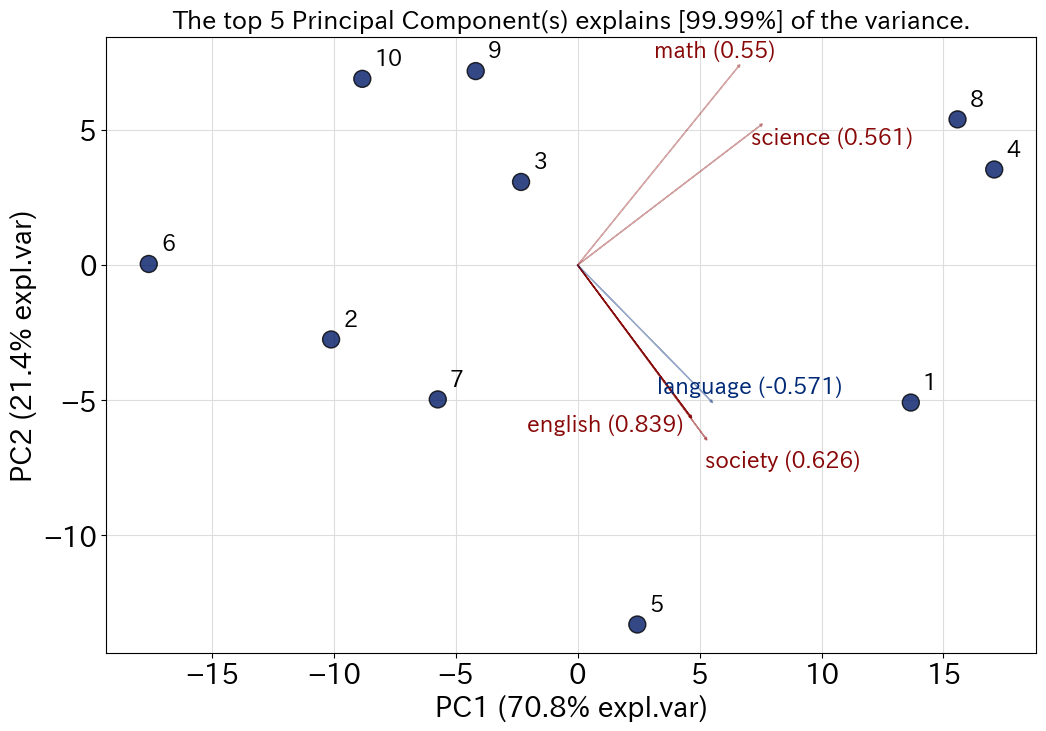

In [23]:
# 主成分分析の結果を可視化（バイプロット）
pc_no = my_data['No'].values
pc_scores = my_result['PC']
pc1 = pc_scores['PC1'].values
pc2 = pc_scores['PC2'].values
fig, ax = my_model.biplot(legend=True, figsize=(12, 8), fontsize=16)
for i in range(len(pc_no)):
  ax.annotate(f"{pc_no[i]}", xy=(pc1[i]+0.5, pc2[i]+0.5))
# ax.annotate(f"{pc_no[0]}", xy=(pc1[0], pc2[0]))

バイプロットの書いてある矢印は正規化した固有ベクトルである．どの科目のベクトルも第1主成分の負の方向を向いている．これは全科目が高得点だと第1主成分が小さくなることを示し，第1主成分は総合力を表す主成分であることを意味する．

文系科目のベクトルがPC2軸の上方向を向いており，理系科目のベクトルがPC2軸の下方向を向いていることが分かる．

バイプロットから，4番，8番，1番は第1主成分の値が小さく，総合能力が高いことが分かる．一方で6番の学生は第1主成分の値が高いことから，総合能力が低いことが分かる．

第2主成分が大きな値の5番の学生は文系科目が得意な文化系の学生であることが分かる．8番, 9番, 10番は第2主成分の値が小さく，理系科目が得意な理科系の学生ということがひと目で分かる．

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Cumulative explained variance.\n The top 5 Principal Component(s) explains [99.99%] of the variance.'}, xlabel='Principal Component', ylabel='Percentage explained variance'>)

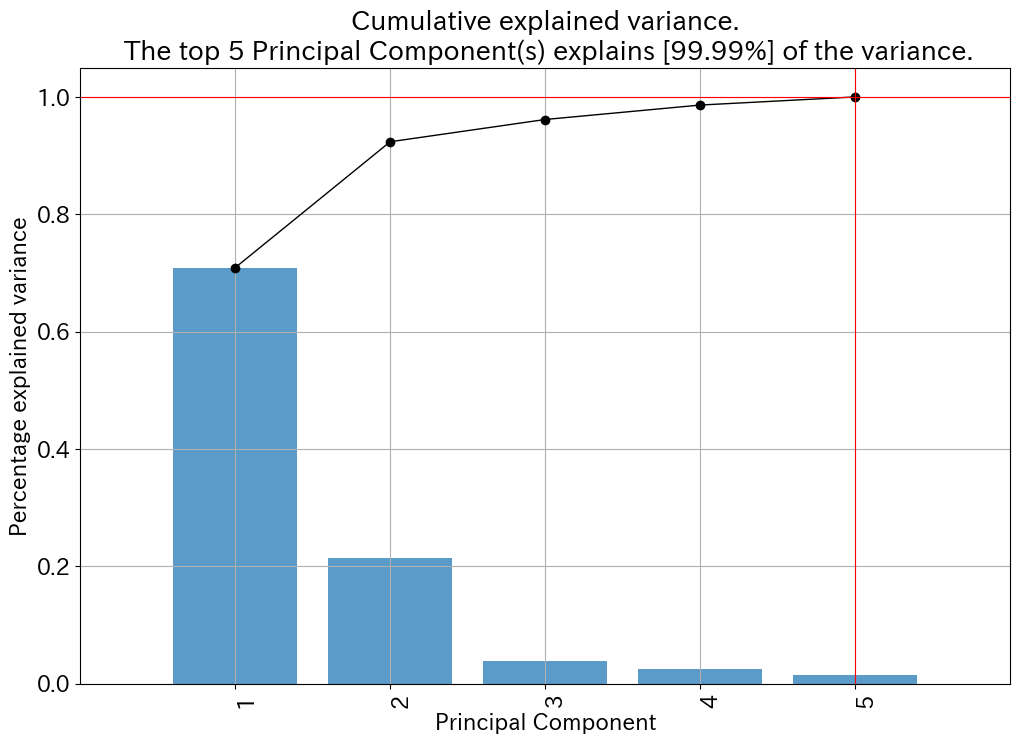

In [24]:
# 累積寄与率をプロット
my_model.plot(figsize=(12, 8))

In [25]:
my_result['explained_var']

array([0.70887164, 0.92357274, 0.9615261 , 0.98614384, 1.        ])

累積寄与率は第1主成分から順番に見たときのデータ分布の情報の説明能力を表している．第2主成分までの累積寄与率が0.9236であることが分かる．したがって第1主成分と第2主成分に全体の情報のうち92%が要約されていることが分かる．

元データには5個の変数があるけども，うまく変数を取ることで（座標変換），2個の変数だけで，受験者の差異（ばらつき）の92%が表現できる，ということ．